In [1]:
# Single Colab cell: Upgraded Combined MRI visualization + realtime Dream-like generator + reference image blending + video+audio
# Paste the whole block into ONE Colab cell and run.

# ---------------------------
# Installs (lightweight)
# ---------------------------
!pip install -q nibabel scikit-image scipy imageio imageio-ffmpeg ipywidgets reportlab matplotlib pillow librosa soundfile

# Enable widgets in Colab (sometimes necessary)
try:
    from google.colab import output as _output
    _output.enable_custom_widget_manager()
except Exception:
    pass

# ---------------------------
# Imports
# ---------------------------
import os
import io
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from skimage import transform, data, measure
from scipy import ndimage
import imageio
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from google.colab import files
from ipywidgets import interact, IntSlider, Dropdown, Textarea, IntText, Button, HBox, VBox, Checkbox
from PIL import Image, ImageFilter, ImageOps, ImageEnhance, ImageChops
import soundfile as sf
import librosa
import tempfile
import math
import random
import warnings
from IPython.display import display, clear_output
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.4 MB/s eta 0:00:00


In [2]:
# ---------------------------
# Utilities (HSV->RGB helper)
# ---------------------------
def hsv_to_rgb_tuple(h, s, v):
    # expects h in [0,1], s in [0,1], v in [0,1]
    if s == 0.0:
        r = g = b = int(v * 255)
        return (r, g, b)
    i = int(h * 6.0)  # sector 0..5
    f = (h * 6.0) - i
    p = v * (1.0 - s)
    q = v * (1.0 - s * f)
    t = v * (1.0 - s * (1.0 - f))
    i = i % 6
    if i == 0:
        r, g, b = v, t, p
    elif i == 1:
        r, g, b = q, v, p
    elif i == 2:
        r, g, b = p, v, t
    elif i == 3:
        r, g, b = p, q, v
    elif i == 4:
        r, g, b = t, p, v
    else:
        r, g, b = v, p, q
    return (int(r*255), int(g*255), int(b*255))

In [3]:
# ---------------------------
# --- MRI functions (as before, lightly refactored) ---
# ---------------------------
def load_nifti(path):
    img = nib.load(str(path))
    data = img.get_fdata().astype(float)
    return data, getattr(img, 'affine', None)

def make_synthetic_brain(shape=(128,128,128), lesion_center=None, lesion_radius=10, noise=0.05):
    ph = data.shepp_logan_phantom()
    ph = transform.resize(ph, (shape[1], shape[2]), preserve_range=True)
    vol = np.stack([ph for _ in range(shape[0])], axis=0)
    vol = vol / vol.max()
    vol = vol + noise * np.random.randn(*vol.shape)
    vol = (vol - vol.min()) / (vol.max() - vol.min())
    if lesion_center is None:
        lesion_center = (shape[0]//2 + 8, shape[1]//2 - 6, shape[2]//2 + 4)
    zz, yy, xx = np.indices(shape)
    dist = np.sqrt((zz - lesion_center[0])**2 + (yy - lesion_center[1])**2 + (xx - lesion_center[2])**2)
    lesion_mask = dist <= lesion_radius
    vol[lesion_mask] += 0.6
    vol = np.clip(vol, 0, 1)
    return vol

def detect_abnormalities(volume, method='zscore', z_thresh=2.5):
    mu = np.mean(volume)
    sigma = np.std(volume)
    z = (volume - mu) / (sigma + 1e-12)
    mask = z > z_thresh
    return mask, mu, sigma

def get_brain_mask(volume, thresh=None):
    if thresh is None:
        thresh = np.percentile(volume, 5) + 0.05*(np.max(volume)-np.min(volume))
    return volume > thresh

def analyze_mask(mask, brain_mask):
    labeled, ncomp = ndimage.label(mask)
    if ncomp > 0:
        centers = ndimage.center_of_mass(mask, labels=labeled, index=range(1, ncomp+1))
    else:
        centers = []
    abnormal_vox = mask.sum()
    brain_vox = brain_mask.sum()
    frac = abnormal_vox / (brain_vox + 1e-12)
    return {'n_clusters': int(ncomp), 'centroids': centers, 'abnormal_voxels': int(abnormal_vox),
            'brain_voxels': int(brain_vox), 'fraction': float(frac)}

def overlay_slice_colors(slice_img, slice_mask, brain_mask_slice):
    h, w = slice_img.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    rgb[(brain_mask_slice) & (~slice_mask)] = np.array([0, 255, 0], dtype=np.uint8)
    rgb[slice_mask] = np.array([255, 0, 0], dtype=np.uint8)
    return rgb

def show_interactive_slices(volume, mask, brain_mask):
    nz = volume.shape[0]
    @interact(slice_idx=IntSlider(min=0, max=nz-1, step=1, value=nz//2))
    def _show(slice_idx= nz//2):
        slice_img = volume[slice_idx]
        slice_mask = mask[slice_idx].astype(bool)
        brain_mask_slice = brain_mask[slice_idx].astype(bool)
        rgb = overlay_slice_colors(slice_img, slice_mask, brain_mask_slice)
        plt.figure(figsize=(6,6))
        plt.imshow(rgb)
        plt.title(f"Slice {slice_idx} — red = abnormal, green = normal")
        plt.axis('off')
        plt.show()

def save_mip_rotation_gif(volume, mask, out_path='rotation.gif', n_frames=36):
    frames = []
    brain_mip_ref = np.max(volume, axis=0)
    brain_mip_mask = brain_mip_ref > np.percentile(brain_mip_ref, 30)
    for angle in np.linspace(0, 360, n_frames, endpoint=False):
        vol_rot = ndimage.rotate(mask.astype(float), angle, axes=(1,2), reshape=False, order=0, mode='constant', cval=0.0)
        mip = np.max(vol_rot, axis=0) > 0.5
        h,w = mip.shape
        frame = np.zeros((h,w,3), dtype=np.uint8)
        frame[(brain_mip_mask) & (~mip)] = [0,255,0]
        frame[mip] = [255,0,0]
        frames.append(frame)
    imageio.mimsave(out_path, frames, fps=8)
    return out_path

def save_pdf_report(out_pdf_path, summary_text, images_to_embed):
    c = canvas.Canvas(out_pdf_path, pagesize=letter)
    width, height = letter
    left = 50
    top = height - 50
    c.setFont("Helvetica-Bold", 16)
    c.drawString(left, top, "Brain Data Analysis Report")
    c.setFont("Helvetica", 10)
    y = top - 30
    for line in summary_text.splitlines():
        if y < 120:
            c.showPage()
            y = height - 50
        c.drawString(left, y, line)
        y -= 14
    for img_path in images_to_embed:
        if y < 250:
            c.showPage()
            y = height - 50
        try:
            c.drawImage(str(img_path), left, y-200, width=400, height=200, preserveAspectRatio=True)
        except Exception as e:
            c.drawString(left, y, f"Could not embed image {img_path}: {e}")
        y -= 220
    c.save()
    return out_pdf_path


In [4]:
# ---------------------------
# --- Dream-like generator (improved) ---
# ---------------------------

def perlin_noise(width, height, scale=8, seed=None):
    # Multi-octave smoothed random -> Perlin-like
    if seed is not None:
        rnd = np.random.RandomState(seed)
    else:
        rnd = np.random.RandomState()
    def smooth_noise(shape, freq):
        base = rnd.rand(*((int(math.ceil(shape[0]/freq))+2, int(math.ceil(shape[1]/freq))+2)))
        base = Image.fromarray((base*255).astype(np.uint8)).resize((shape[1], shape[0]), Image.BILINEAR)
        arr = np.array(base).astype(np.float32)/255.0
        return arr
    noise = np.zeros((height, width), dtype=np.float32)
    persistence = 0.5
    octaves = 5
    amplitude = 1.0
    total_amp = 0.0
    for o in range(octaves):
        freq = max(1, scale / (2**o))
        noise += amplitude * smooth_noise((height, width), freq)
        total_amp += amplitude
        amplitude *= persistence
    noise /= (total_amp + 1e-12)
    return noise

def text_to_seed(prompt):
    return abs(hash(prompt)) % (2**32)

def blend_with_reference(frame_img, ref_img, strength=0.35):
    # ref_img: PIL RGB, frame_img: PIL RGB
    # Resize ref to frame size
    try:
        ref = ref_img.resize(frame_img.size).convert('RGB')
        # use a soft overlay: color dodge-ish by lighten and add noise
        blended = Image.blend(frame_img, ref, alpha=strength)
        # add subtle channel shift from reference edges
        edges = ref.convert('L').filter(ImageFilter.FIND_EDGES).convert('RGB')
        shifted = ImageChops.offset(blended, int(3*strength), -int(2*strength))
        final = Image.blend(blended, shifted, alpha=0.2*strength)
        return final
    except Exception:
        return frame_img

def make_dream_frame(prompt, width=512, height=512, t=0.0, seed=None, style_strength=0.6, ref_img=None, ref_strength=0.25):
    # Build colorful surreal frame; if ref_img provided, blend it in
    if seed is None:
        seed = text_to_seed(prompt)
    rnd = np.random.RandomState((seed + int(t*1000)) % (2**32))
    # base gradient background
    arr = np.zeros((height, width, 3), dtype=np.uint8)
    # pick two hues
    hue1 = ((seed % 360) / 360.0)
    hue2 = (((seed // 7) % 360) / 360.0)
    for x in range(width):
        blend = x / float(max(1, width-1))
        h = hue1*(1-blend) + hue2*blend
        r,g,b = hsv_to_rgb_tuple(h, 0.6 + 0.2*rnd.rand(), 0.6 + 0.3*rnd.rand())
        arr[:, x, 0] = r
        arr[:, x, 1] = g
        arr[:, x, 2] = b
    bg = Image.fromarray(arr)
    # color splashes via perlin noise
    n = perlin_noise(width, height, scale=16, seed=seed+7)
    color_map = (np.stack([n, np.roll(n, width//4, axis=1), np.roll(n, width//2, axis=1)], axis=2) * 255).astype(np.uint8)
    color_img = Image.fromarray(color_map).filter(ImageFilter.GaussianBlur(radius=6*style_strength))
    img = Image.blend(bg, color_img, alpha=0.6)
    # neuron blobs
    draw_layer = Image.new('RGBA', (width, height), (0,0,0,0))
    dr = np.array(draw_layer)
    num_blobs = 4 + rnd.randint(0,8)
    for i in range(num_blobs):
        cx = rnd.randint(0, width-1)
        cy = rnd.randint(0, height-1)
        r = int((min(width,height)//6) * (0.3 + rnd.rand()*1.6) * (1.0 + 0.6*style_strength))
        y,x = np.ogrid[-cy:height-cy, -cx:width-cx]
        mask = x*x + y*y <= r*r
        color = tuple(int(100 + 155*rnd.rand()) for _ in range(3)) + (int(50 + 160*rnd.rand()),)
        dr[mask] = color
    overlay = Image.fromarray(dr, 'RGBA').filter(ImageFilter.GaussianBlur(radius=int(8*style_strength)))
    img = Image.alpha_composite(img.convert('RGBA'), overlay).convert('RGB')
    # color and blur tweaks
    enhancer = ImageEnhance.Color(img)
    img = enhancer.enhance(1.2 + rnd.rand()*1.2*style_strength)
    img = img.filter(ImageFilter.GaussianBlur(radius=0.6 + rnd.rand()*2.0*style_strength))
    # small channel shift
    arr = np.array(img).astype(np.int16)
    shift = int(3 * style_strength)
    for ch in range(3):
        arr[..., ch] = np.roll(arr[..., ch], shift * (ch-1), axis=1)
    img = Image.fromarray(np.clip(arr,0,255).astype(np.uint8))
    # vignette
    cx, cy = width//2, height//2
    xv, yv = np.meshgrid(np.arange(width), np.arange(height))
    dist = np.sqrt(((xv-cx)/cx)**2 + ((yv-cy)/cy)**2)
    vign = 1.0 - np.clip(dist, 0, 1)**1.5
    arr = np.array(img).astype(np.float32)
    arr[..., 0] *= vign
    arr[..., 1] *= vign
    arr[..., 2] *= vign
    img = Image.fromarray(np.clip(arr,0,255).astype(np.uint8))
    # blend with reference image if provided
    if ref_img is not None:
        img = blend_with_reference(img, ref_img, strength=ref_strength*style_strength)
    return img

def generate_dream_sequence(prompt, n_frames=48, width=640, height=360, style_strength=0.6, out_dir=None,
                            ref_image_path=None, realtime_preview=True, preview_interval=0.05):
    if out_dir is None:
        out_dir = Path(tempfile.mkdtemp(prefix="dream_"))
    else:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
    seed = text_to_seed(prompt)
    # load reference image if exists
    ref_img = None
    if ref_image_path is not None and Path(ref_image_path).exists():
        try:
            ref_img = Image.open(str(ref_image_path)).convert('RGB')
        except Exception:
            ref_img = None
    paths = []
    # create preview display once
    if realtime_preview:
        display_handle = None
    for i in range(n_frames):
        t = i / max(1, n_frames)
        frame = make_dream_frame(prompt, width=width, height=height, t=t, seed=seed, style_strength=style_strength, ref_img=ref_img, ref_strength=0.35)
        # small motion transform
        dx = int(6 * style_strength * math.sin(2*math.pi*t))
        dy = int(6 * style_strength * math.cos(2*math.pi*t))
        frame = frame.transform(frame.size, Image.AFFINE, (1, 0.0, -dx, 0.0, 1, -dy))
        p = out_dir / f"frame_{i:04d}.png"
        frame.save(p, quality=90)
        paths.append(str(p))
        if realtime_preview:
            clear_output(wait=True)
            display(frame.resize((min(800, width), int(min(800, width) * height/width))))
            # small pause so notebook shows it progressively
            try:
                import time
                time.sleep(preview_interval)
            except Exception:
                pass
    return paths, out_dir

def frames_to_video(frame_paths, out_path, fps=16):
    imgs = []
    for p in frame_paths:
        imgs.append(imageio.imread(p))
    imageio.mimwrite(out_path, imgs, fps=fps, macro_block_size=None)
    return out_path

def synthesize_ambient_music(duration_s=12, sr=22050, prompt_seed=0, complexity=0.5, outfile='ambient.wav'):
    rnd = np.random.RandomState(int(prompt_seed) & 0xffffffff)
    t = np.linspace(0, duration_s, int(sr*duration_s))
    audio = np.zeros_like(t)
    base_freqs = [110, 146.83, 196.0, 261.63]
    freqs = [base_freqs[int((prompt_seed >> (8*i)) % len(base_freqs))] * (1 + 0.01*rnd.randn()) for i in range(3)]
    for f in freqs:
        amp = 0.15 * (0.6 + complexity*0.8)
        lfo = 0.5*(1 + np.sin(2*np.pi*(0.03 + rnd.rand()*0.05)*t + rnd.rand()*2*np.pi))
        audio += amp * lfo * np.sin(2*np.pi*f*t + rnd.rand()*2*np.pi)
    noise = rnd.randn(len(t))
    kernel_size = int(sr * (1.0 - complexity) * 0.5) + 1
    if kernel_size < 1: kernel_size = 1
    noise_smooth = np.convolve(noise, np.ones(kernel_size)/kernel_size, mode='same')
    noise_pad = 0.06 * noise_smooth * (0.5 + complexity)
    audio += noise_pad
    fade_in = int(sr*1.5)
    fade_out = int(sr*1.5)
    fade = np.ones_like(t)
    fade[:fade_in] = np.linspace(0,1,fade_in)
    fade[-fade_out:] = np.linspace(1,0,fade_out)
    audio *= fade
    audio = audio / (np.max(np.abs(audio)) + 1e-12) * 0.8
    sf.write(outfile, audio.astype(np.float32), sr)
    return outfile

In [5]:
# ---------------------------
# --- Combined interactive UI & default flows
# ---------------------------

print("Upgraded Combined MRI visualization + Realtime Dream-like generator (image + video + audio).")
print("1) Upload a NIfTI or skip to use synthetic brain.")
print("2) Optionally use a reference image (e.g., /mnt/data/Screenshot 2025-09-15 222742.png) to blend into dreams.")
print()

# --- MRI upload & run flow ---
print("== MRI: Upload NIfTI or skip to use synthetic demo. (Colab file picker will appear below) ==")
uploaded = files.upload()
input_nifti = None
if uploaded:
    input_dir = Path("/content/input_data")
    input_dir.mkdir(exist_ok=True)
    for fn, blob in uploaded.items():
        p = input_dir / fn
        with open(p, 'wb') as f:
            f.write(blob)
        if fn.endswith('.nii') or fn.endswith('.nii.gz'):
            input_nifti = p
            break

if input_nifti is None:
    print("No NIfTI uploaded: creating synthetic demo brain (has one lesion).")
    volume = make_synthetic_brain(shape=(128,128,128))
else:
    try:
        print("Loading uploaded NIfTI:", input_nifti)
        volume, affine = load_nifti(input_nifti)
        volume = (volume - np.min(volume)) / (np.max(volume) - np.min(volume) + 1e-12)
    except Exception as e:
        print("Could not load NIfTI, falling back to synthetic. Error:", e)
        volume = make_synthetic_brain(shape=(128,128,128))

brain_mask = get_brain_mask(volume)
abnormal_mask, mu, sigma = detect_abnormalities(volume, z_thresh=2.5)
analysis = analyze_mask(abnormal_mask, brain_mask)
print("Analysis summary:", analysis)
print("Interactive slice viewer (use slider to browse slices):")
show_interactive_slices(volume, abnormal_mask, brain_mask)

# Save representative slices and rotation GIF
out_dir = Path("/content/output_brain")
out_dir.mkdir(exist_ok=True)
center_slice = volume.shape[0]//2
for idx in [center_slice-10, center_slice, center_slice+10]:
    if 0 <= idx < volume.shape[0]:
        slice_img = volume[idx]
        slice_mask = abnormal_mask[idx].astype(bool)
        brain_mask_slice = brain_mask[idx].astype(bool)
        rgb = overlay_slice_colors(slice_img, slice_mask, brain_mask_slice)
        path = out_dir / f"slice_{idx}.png"
        plt.imsave(path, rgb)
        print("Saved slice view:", path)
gif_path = out_dir / "brain_rotation.gif"
gif_path = save_mip_rotation_gif(volume, abnormal_mask, out_path=str(gif_path), n_frames=36)
print("Saved rotation GIF:", gif_path)
summary_lines = [
    f"Mean intensity: {mu:.4f}, Std: {sigma:.4f}",
    f"Abnormal clusters detected: {analysis['n_clusters']}",
    f"Abnormal voxels: {analysis['abnormal_voxels']} / brain voxels: {analysis['brain_voxels']}",
    f"Fraction of brain volume flagged: {analysis['fraction']*100:.4f} %"
]
centroids = analysis['centroids'][:5] if analysis['centroids'] else []
for i, c in enumerate(centroids, start=1):
    summary_lines.append(f"Cluster {i} centroid (z,y,x): {tuple(float(round(v,2)) for v in c)}")
summary_text = "\n".join(summary_lines)
images_to_embed = list(out_dir.glob("slice_*.png")) + [gif_path]
pdf_path = out_dir / "brain_report.pdf"
save_pdf_report(str(pdf_path), summary_text, images_to_embed)
print("Saved PDF report:", pdf_path)

print("\nOutputs saved in:", out_dir)
for p in out_dir.iterdir():
    print("-", p.name)


Upgraded Combined MRI visualization + Realtime Dream-like generator (image + video + audio).
1) Upload a NIfTI or skip to use synthetic brain.
2) Optionally use a reference image (e.g., /mnt/data/Screenshot 2025-09-15 222742.png) to blend into dreams.

== MRI: Upload NIfTI or skip to use synthetic demo. (Colab file picker will appear below) ==


Saving SC4101EC-Hypnogram.edf to SC4101EC-Hypnogram.edf
No NIfTI uploaded: creating synthetic demo brain (has one lesion).
Analysis summary: {'n_clusters': 2, 'centroids': [(np.float64(63.51599976496856), np.float64(50.18601562959046), np.float64(63.4999588694988)), (np.float64(72.0), np.float64(58.0), np.float64(68.0))], 'abnormal_voxels': 89264, 'brain_voxels': 1452294, 'fraction': 0.06146413880385101}
Interactive slice viewer (use slider to browse slices):


interactive(children=(IntSlider(value=64, description='slice_idx', max=127), Output()), _dom_classes=('widget-…

Saved slice view: /content/output_brain/slice_54.png
Saved slice view: /content/output_brain/slice_64.png
Saved slice view: /content/output_brain/slice_74.png
Saved rotation GIF: /content/output_brain/brain_rotation.gif
Saved PDF report: /content/output_brain/brain_report.pdf

Outputs saved in: /content/output_brain
- slice_54.png
- brain_rotation.gif
- slice_64.png
- slice_74.png
- brain_report.pdf


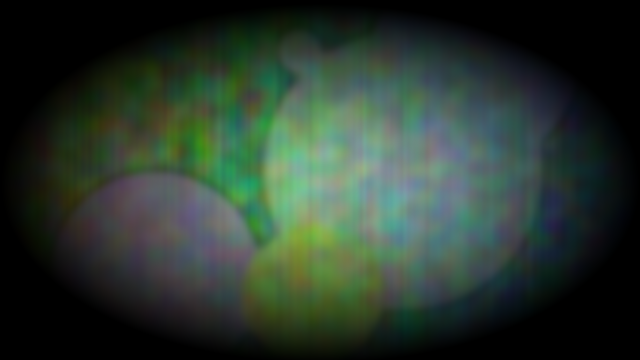

Saved dream video: /content/dream_video_89050.mp4
Synthesizing ambient audio...
Saved ambient audio: /content/ambient_89050.wav
Created muxed video with audio: /content/dream_video_with_audio_89050.mp4

--- DONE ---
Files you can download from Colab session:
- /content/output_brain/brain_report.pdf
- /content/output_brain/brain_rotation.gif
- /content/dream_video_89050.mp4
- /content/ambient_89050.wav
- /content/dream_video_with_audio_89050.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


If you want to swap in Stable Diffusion or MusicGen later, replace the 'make_dream_frame' or 'synthesize_ambient_music' hooks with your model calls.


In [7]:
# ---------------------------
# Dream generator parameters (text prompt, etc.)
# ---------------------------
print("\n== Dream-like generator ==")
print("You will be prompted for a short text prompt. Press Enter to accept defaults.")
prompt = input("\nEnter dream prompt (default: 'A surreal dream of neurons glowing in a cosmic ocean'): ") or "A surreal dream of neurons glowing in a cosmic ocean"
n_frames = int(input("Frames (e.g., 48): ") or 48)
width = int(input("Frame width (e.g., 640): ") or 640)
height = int(input("Frame height (e.g., 360): ") or 360)
style_strength = float(input("Style strength 0.0-1.0 (e.g., 0.6): ") or 0.6)
audio_duration = float(input("Audio length seconds (e.g., 12): ") or 12.0)
use_ref = input("Use reference image from /mnt/data? (y/n) [default y if exists]: ") or "y"

# try defaultref
default_ref_path = Path("/mnt/data/Screenshot 2025-09-15 222742.png")
ref_path = None
if use_ref.lower().startswith('y'):
    if default_ref_path.exists():
        print("Using reference image:", default_ref_path)
        ref_path = str(default_ref_path)
    else:
        # ask user to upload an image or skip
        print("No default image found at /mnt/data. You may upload a reference image now (optional).")
        ref_uploaded = files.upload()
        if ref_uploaded:
            for fn, blob in ref_uploaded.items():
                p = Path("/content") / fn
                with open(p, 'wb') as f:
                    f.write(blob)
                ref_path = str(p)
                break
        if ref_path is None:
            print("No reference image provided; continuing without a reference image.")
            ref_path = None

print("\nGenerating frames (realtime preview will appear)...")
dream_out_dir = Path("/content/dream_out")
dream_out_dir.mkdir(exist_ok=True)
frame_paths, dream_dir = generate_dream_sequence(prompt, n_frames=n_frames, width=width, height=height,
                                                 style_strength=style_strength, out_dir=str(dream_out_dir),
                                                 ref_image_path=ref_path, realtime_preview=True, preview_interval=0.03)
video_out = Path("/content") / f"dream_video_{abs(hash(prompt))%100000}.mp4"
frames_to_video(frame_paths, str(video_out), fps=16)
print("Saved dream video:", video_out)

print("Synthesizing ambient audio...")
audio_out = Path("/content") / f"ambient_{abs(hash(prompt))%100000}.wav"
synthesize_ambient_music(duration_s=audio_duration, sr=22050, prompt_seed=text_to_seed(prompt), complexity=style_strength, outfile=str(audio_out))
print("Saved ambient audio:", audio_out)

# Attempt to mux audio + video using ffmpeg
try:
    import subprocess
    muxed = Path("/content") / f"dream_video_with_audio_{abs(hash(prompt))%100000}.mp4"
    cmd = [
        "ffmpeg", "-y",
        "-i", str(video_out),
        "-i", str(audio_out),
        "-c:v", "copy",
        "-c:a", "aac",
        "-shortest",
        str(muxed)
    ]
    subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=False)
    if muxed.exists():
        print("Created muxed video with audio:", muxed)
        final_video = muxed
    else:
        final_video = video_out
except Exception as e:
    print("Could not mux audio+video automatically (ffmpeg error). Using video without audio.")
    final_video = video_out

print("\n--- DONE ---")
print("Files you can download from Colab session:")
candidates = [str(p) for p in [pdf_path, gif_path, video_out, audio_out, final_video] if p is not None]
for c in candidates:
    if Path(c).exists():
        print("-", c)

# Attempt to offer downloads (Colab)
for c in candidates:
    try:
        files.download(c)
    except Exception:
        pass

print("\nIf you want to swap in Stable Diffusion or MusicGen later, replace the 'make_dream_frame' or 'synthesize_ambient_music' hooks with your model calls.")